## **This script can be used to calculate WBGT by crop types. It corresponds to Figures 3 and 6 in the paper "High-resolution modeling of wet-bulb globe temperature reveals substantial heat risks among agricultural workers in Southern California" under review in GeoHealth.**

### To use this script, first download the WBGT data from the following link:

https://drive.google.com/file/d/1DtyoJssOt9BdU-5d5CBNIj_2wQIwz2tM/view?usp=sharing

In [ ]:
# Load the WBGT arrays for April-Oct, 2020
import numpy as np
data = np.load('/content/drive/MyDrive/Google_Drive_UTmail/SDSU/python_colab_data/wbgt_c_apr_oct.npz')
wbgt_c = data['wbgt_gcm_c']
wbgt_c[wbgt_c < -100] = np.nan;
wbgt_f = (wbgt_c * 9 / 5) + 32

print(np.nanmin(wbgt_f), np.nanmax(wbgt_f))
wbgt_f +=5.4; # increase WBGT with clothing correction factor to get wbgt-eff


6.115606669343311 113.60900822506576


In [ ]:
# get model lat and lon information (not required)
import xarray as xr
import numpy as np
import pandas as pd
!pip install netCDF4
import netCDF4 as nc

lat_dataset = nc.Dataset('/content/drive/MyDrive/Google_Drive_UTmail/SDSU/python_colab_data/1km_heatwave_sep_temp.nc')
long_dataset = nc.Dataset('/content/drive/MyDrive/Google_Drive_UTmail/SDSU/python_colab_data/1km_heatwave_sep_temp.nc')
lat = lat_dataset['XLAT'][:]
lon = long_dataset['XLONG'][:]
print(lat.shape)
print(lon.shape)


(171, 162)
(171, 162)


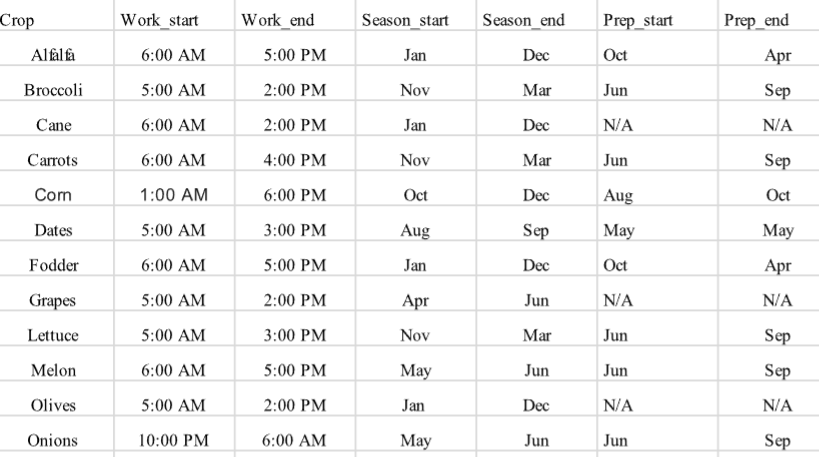

In [ ]:
# View the labor calendar (based on interviews)

from IPython.display import Image
display(Image('/content/drive/MyDrive/Google_Drive_UTmail/SDSU/Figures/crop_calendar.png'))


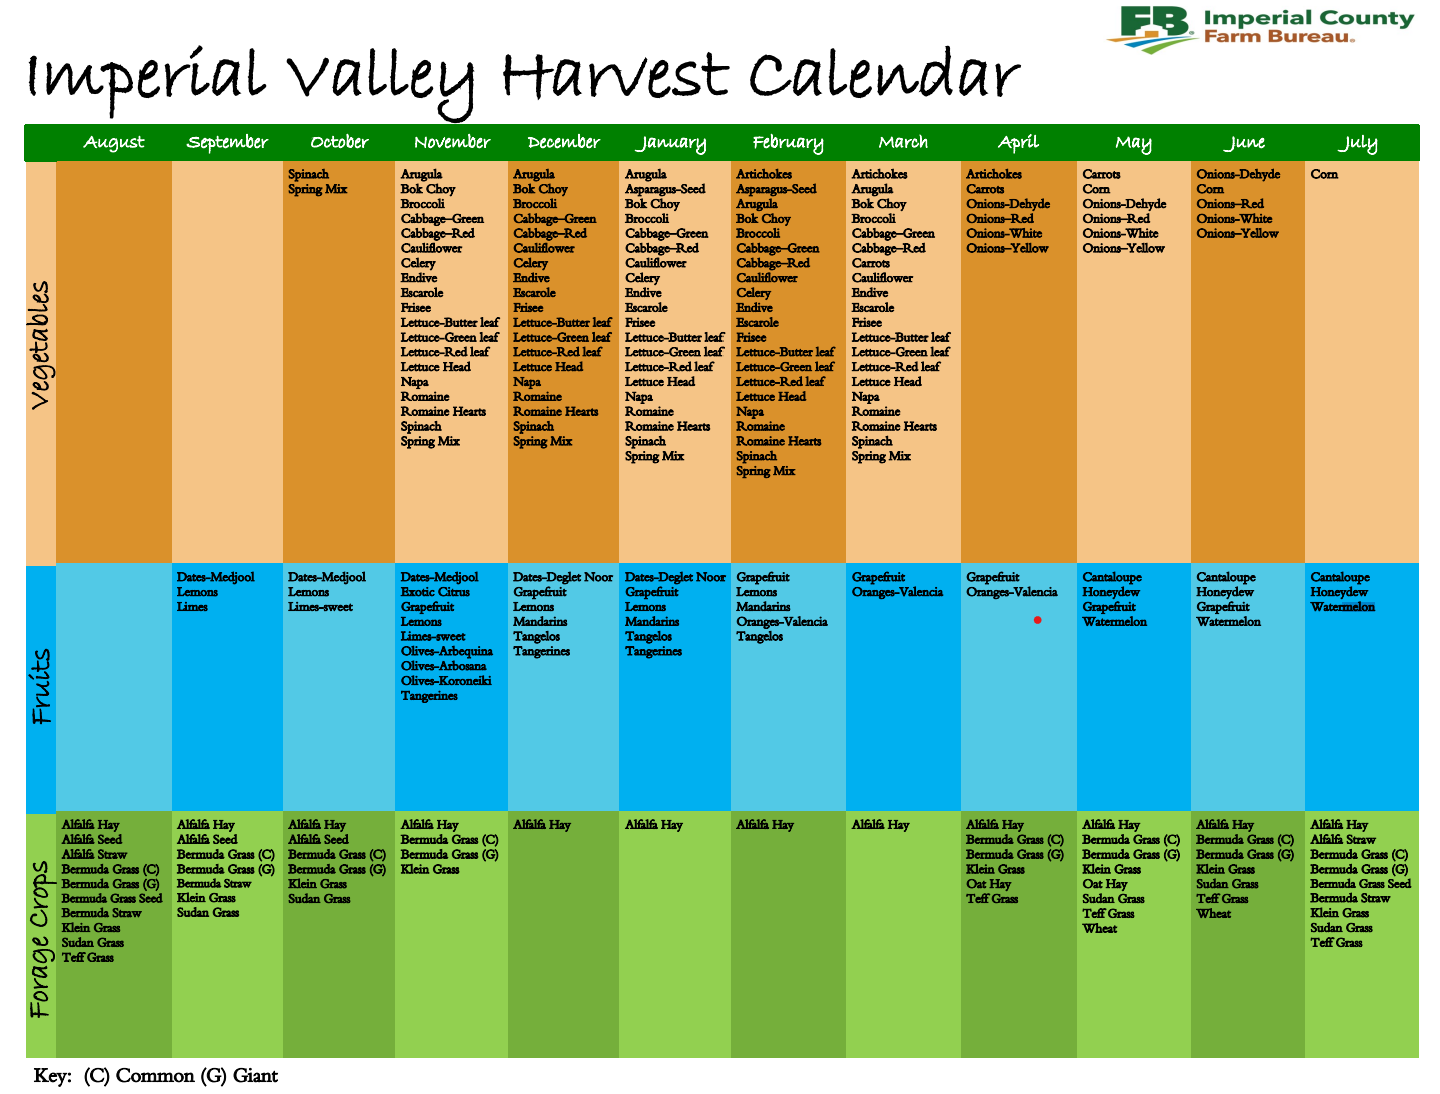

In [ ]:
# View the labor calendar from Imperial County Farm Bureau

from IPython.display import Image
display(Image('/content/drive/MyDrive/Google_Drive_UTmail/SDSU/Figures/crop_calendar_farm_bureau.png'))

In [ ]:

# extract WBGT for IV region

wbgt_f_iv = wbgt_f[:, 20:70, 106:140]; # IV bounding box

wbgt_f_iv_diurnal = np.reshape(wbgt_f_iv, (24, 214, 50, 34), order='F');

wbgt_f_iv_corn = wbgt_f_iv_diurnal[1:18, 30:122, :, :]; # 1:18 hrs, aug-oct (prep time)
wbgt_f_iv_melon = wbgt_f_iv_diurnal[6:17, 30:91, :, :]; # 6:17 hrs, may-june (harvest time)
wbgt_f_iv_onions_day = wbgt_f_iv_diurnal[6:14, 30:91, :, :]; # 6am-2pm, may-june (harvest time)
wbgt_f_iv_onions_night = wbgt_f_iv_diurnal[np.r_[0:1, 18:23], 30:91, :, :]; # 6pm-1am, may-june (harvest time)
wbgt_f_iv_grapes = wbgt_f_iv_diurnal[5:15, 0:91, :, :]; # 5:15 hrs, apr-june (harvest time)
wbgt_f_iv_dates = wbgt_f_iv_diurnal[5:15, 122:183, :, :]; # 5:15 hrs, aug_sep (harvest time)
wbgt_f_iv_winter = wbgt_f_iv_diurnal[6:15, 61:183, :, :]; # 6:15 hrs, june-sep (prep time)
wbgt_f_iv_olives = wbgt_f_iv_diurnal[5:14, 153:214, :, :]; # 5:14 hrs, sep-oct (harvest time)
wbgt_f_iv_cane = wbgt_f_iv_diurnal[6:14, 0:214, :, :]; # 6:14 hrs, apr-oct (harvest time)
wbgt_f_iv_alfalfa_sudan = wbgt_f_iv_diurnal[6:17, 0:214, :, :]; # 6:17 hrs, apr-oct (harvest time)


wbgt_f_coach = wbgt_f[:, 110:160, 15:70];  # Coach bounding box

wbgt_f_coach_diurnal = np.reshape(wbgt_f_coach, (24, 214, 50, 55), order='F');

wbgt_f_coach_corn = wbgt_f_coach_diurnal[1:18, 30:122, :, :];  # 1:18 hrs, Aug-Oct (prep time)
wbgt_f_coach_melon = wbgt_f_coach_diurnal[6:17, 30:91, :, :];  # 6:17 hrs, May-June (harvest time)
wbgt_f_coach_onions_day = wbgt_f_coach_diurnal[6:14, 30:91, :, :];  # 6 AM–2 PM, May-June (harvest time)
wbgt_f_coach_onions_night = wbgt_f_coach_diurnal[np.r_[0:1, 18:23], 30:91, :, :];  # 6 PM–1 AM, May-June (harvest time)
wbgt_f_coach_grapes = wbgt_f_coach_diurnal[5:15, 0:91, :, :];  # 5:15 hrs, Apr–June (harvest time)
wbgt_f_coach_dates = wbgt_f_coach_diurnal[5:15, 122:183, :, :];  # 5:15 hrs, Aug–Sep (harvest time)
wbgt_f_coach_winter = wbgt_f_coach_diurnal[6:15, 61:183, :, :];  # 6:15 hrs, June–Sep (prep time)
wbgt_f_coach_olives = wbgt_f_coach_diurnal[5:14, 153:214, :, :];  # 5:14 hrs, Sep–Oct (harvest time)
wbgt_f_coach_cane = wbgt_f_coach_diurnal[6:14, 0:214, :, :];  # 6:14 hrs, Apr–Oct (harvest time)
wbgt_f_coach_alfalfa_sudan = wbgt_f_coach_diurnal[6:17, 0:214, :, :];  # 6:17 hrs, Apr–Oct (harvest time)




In [ ]:
# Crop-specific average WBGT (averaged over hour and day)

wbgt_avg_corn = np.mean(wbgt_f_iv_diurnal[1:18, 30:122, :, :], axis=(0, 1))
wbgt_avg_melon = np.mean(wbgt_f_iv_diurnal[6:17, 30:91, :, :], axis=(0, 1))
wbgt_avg_onions_day = np.mean(wbgt_f_iv_diurnal[6:14, 30:91, :, :], axis=(0, 1))
wbgt_avg_onions_night = np.mean(wbgt_f_iv_diurnal[np.r_[0:1, 18:23], 30:91, :, :], axis=(0, 1))
wbgt_avg_grapes = np.mean(wbgt_f_iv_diurnal[5:15, 0:91, :, :], axis=(0, 1))
wbgt_avg_dates = np.mean(wbgt_f_iv_diurnal[5:15, 122:183, :, :], axis=(0, 1))
wbgt_avg_winter = np.mean(wbgt_f_iv_diurnal[6:15, 61:183, :, :], axis=(0, 1))
wbgt_avg_olives = np.mean(wbgt_f_iv_diurnal[5:14, 153:214, :, :], axis=(0, 1))
wbgt_avg_cane = np.mean(wbgt_f_iv_diurnal[6:14, 0:214, :, :], axis=(0, 1))
wbgt_avg_alfalfa_sudan = np.mean(wbgt_f_iv_diurnal[6:17, 0:214, :, :], axis=(0, 1))

wbgt_avg_coach_corn = np.mean(wbgt_f_coach_diurnal[1:18, 30:122, :, :], axis=(0, 1))
wbgt_avg_coach_melon = np.mean(wbgt_f_coach_diurnal[6:17, 30:91, :, :], axis=(0, 1))
wbgt_avg_coach_onions_day = np.mean(wbgt_f_coach_diurnal[6:14, 30:91, :, :], axis=(0, 1))
wbgt_avg_coach_onions_night = np.mean(wbgt_f_coach_diurnal[np.r_[0:1, 18:23], 30:91, :, :], axis=(0, 1))
wbgt_avg_coach_grapes = np.mean(wbgt_f_coach_diurnal[5:15, 0:91, :, :], axis=(0, 1))
wbgt_avg_coach_dates = np.mean(wbgt_f_coach_diurnal[5:15, 122:183, :, :], axis=(0, 1))
wbgt_avg_coach_winter = np.mean(wbgt_f_coach_diurnal[6:15, 61:183, :, :], axis=(0, 1))
wbgt_avg_coach_olives = np.mean(wbgt_f_coach_diurnal[5:14, 153:214, :, :], axis=(0, 1))
wbgt_avg_coach_cane = np.mean(wbgt_f_coach_diurnal[6:14, 0:214, :, :], axis=(0, 1))
wbgt_avg_coach_alfalfa_sudan = np.mean(wbgt_f_coach_diurnal[6:17, 0:214, :, :], axis=(0, 1))


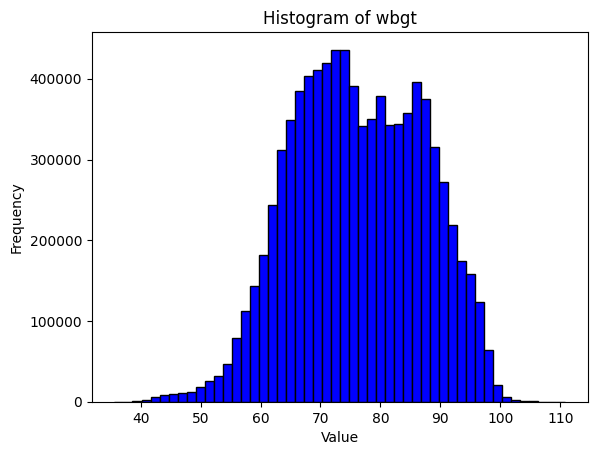

In [ ]:
# check data
import numpy as np
import matplotlib.pyplot as plt

# Assuming lab_prod is your 4D array
plt.hist(wbgt_f_iv.flatten(), bins=50, color='blue', edgecolor='black')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Histogram of wbgt')
plt.show()


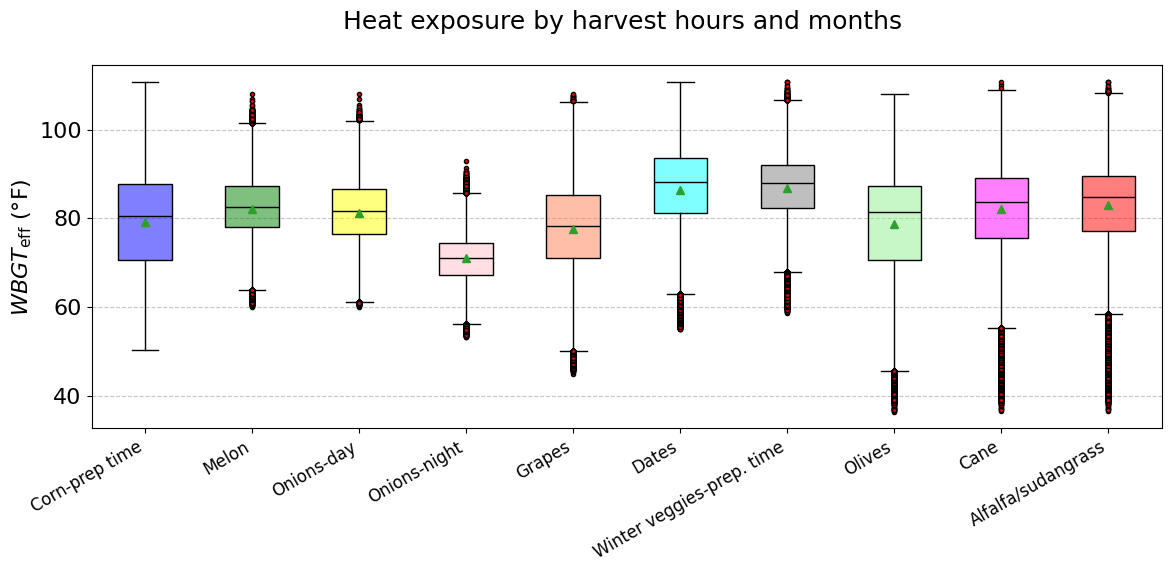

In [ ]:
# Create box plots of WBGT by crop types

import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 16})
# Flatten the arrays
data = {
    "Corn-prep time": wbgt_f_iv_corn.flatten(),
    "Melon": wbgt_f_iv_melon.flatten(),
    "Onions-day": wbgt_f_iv_onions_day.flatten(),
    "Onions-night": wbgt_f_iv_onions_night.flatten(),
    "Grapes": wbgt_f_iv_grapes.flatten(),
    "Dates": wbgt_f_iv_dates.flatten(),
    "Winter veggies-prep. time": wbgt_f_iv_winter.flatten(),
    "Olives": wbgt_f_iv_olives.flatten(),
    "Cane": wbgt_f_iv_cane.flatten(),
    "Alfalfa/sudangrass": wbgt_f_iv_alfalfa_sudan.flatten(),
    }

for key in data:
    data[key] = np.where(data[key] < 30, np.nan, data[key]) # remove erroneous values < 30 with nan

# Step 2: Remove NaN values
data = {key: arr[~np.isnan(arr)] for key, arr in data.items()} # now remove nan values

# Colors for each crop
#colors = ['lightblue', 'lightgreen', 'lightyellow', 'lightpink', 'lightcoral', 'lightcyan', 'lightgray', 'lightsalmon', 'lightgoldenrodyellow', 'lightseagreen']

import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba

base_colors = ['blue', 'green', 'yellow', 'pink', 'coral',
               'cyan', 'gray', 'lightgreen', 'magenta', 'red']

colors = [to_rgba(color, alpha=0.5) for color in base_colors]


# Create the box plot
plt.figure(figsize=(12, 6))
box = plt.boxplot(
    data.values(),
    patch_artist=True,  # Enable box fill
    boxprops=dict(color='black', linewidth=1),  # Box border
    medianprops=dict(color='black', linewidth=1),  # Median line
    showmeans=True,
    whiskerprops=dict(color='black', linewidth=1),  # Whisker line
    capprops=dict(color='black', linewidth=1),  # Caps on whiskers
    flierprops=dict(marker='o', color='black', markersize=3, markerfacecolor='red')  # Outliers
)

# Set colors for boxes
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

# Customize the plot
plt.xticks(range(1, len(data) + 1), data.keys(), rotation=30, ha='right', fontsize=12)
plt.ylabel("$WBGT_{\\mathrm{eff}}$ (°F)", fontsize=16)
plt.title("Heat exposure by harvest hours and months \n", fontsize=18)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()
##plt.savefig('/content/drive/MyDrive/Google_Drive_UTmail/SDSU/papers/crop/Figures/wbgt_by_crops.png', bbox_inches='tight', dpi=400)


In [ ]:

# Calculate parameters required for plotting WBGT vs. Metabolic Rates

import numpy as np
import matplotlib.pyplot as plt

# Metabolic ranges from literature

m_range_corn = np.array([244,310])
m_range_melon = np.array([231, 293])
m_range_onions_day = np.array([217, 275])
m_range_onions_night = np.array([217, 275])
m_range_grapes = np.array([258, 327])
m_range_dates = np.array([200, 260])
m_range_winter = np.array([146, 181])
m_range_olives = np.array([285, 361])
m_range_cane = np.array([737, 770])

# WBGT ranges from the data

wbgt_range_corn = [wbgt_avg_corn.min(), wbgt_avg_corn.max()]
wbgt_range_melon = [wbgt_avg_melon.min(), wbgt_avg_melon.max()]
wbgt_range_onions_day = [wbgt_avg_onions_day.min(), wbgt_avg_onions_day.max()]
wbgt_range_onions_night = [wbgt_avg_onions_night.min(), wbgt_avg_onions_night.max()]
wbgt_range_grapes = [wbgt_avg_grapes.min(), wbgt_avg_grapes.max()]
wbgt_range_dates = [wbgt_avg_dates.min(), wbgt_avg_dates.max()]
wbgt_range_winter = [wbgt_avg_winter.min(), wbgt_avg_winter.max()]
wbgt_range_olives = [wbgt_avg_olives.min(), wbgt_avg_olives.max()]
wbgt_range_cane = [wbgt_avg_cane.min(), wbgt_avg_cane.max()]
wbgt_range_alfalfa_sudan = [wbgt_avg_alfalfa_sudan.min(), wbgt_avg_alfalfa_sudan.max()]


# Create the standard RAL and REL curves

M = np.arange(100, 801, 10)
M.shape

RAL_C = 59.9 - 14.1 * np.log10(M)
REL_C = 56.7 - 11.5 * np.log10(M)

RAL_F = (RAL_C * 9/5) + 32
REL_F = (REL_C * 9/5) + 32

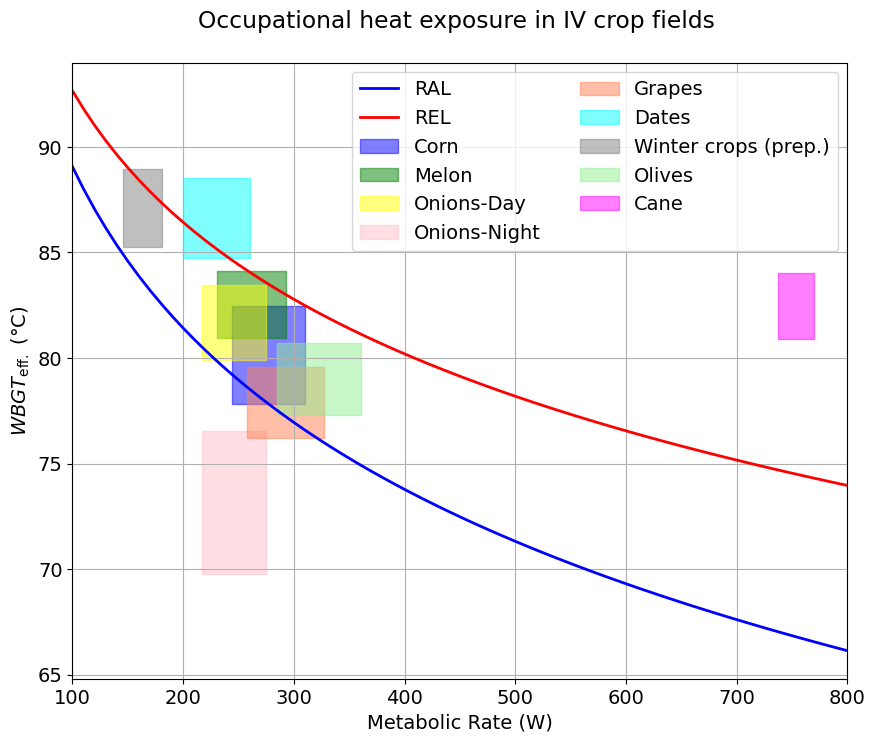

In [ ]:

# Plot the WBGT vs. Metabolic rates

import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.rcParams.update({'font.size': 14})

plt.plot(M, RAL_F, color='blue', linewidth=2, label='RAL')
plt.plot(M, REL_F, color='red', linewidth=2, label='REL')
plt.fill_between(m_range_corn, wbgt_range_corn[0], wbgt_range_corn[1], color='blue', alpha=0.5, label='Corn')  # Filling rectangle with light color
plt.fill_between(m_range_melon, wbgt_range_melon[0], wbgt_range_melon[1], color='green', alpha=0.5, label='Melon')  # Filling rectangle with light color
plt.fill_between(m_range_onions_day, wbgt_range_onions_day[0], wbgt_range_onions_day[1], color='yellow', alpha=0.5, label='Onions-Day')  # Filling rectangle with light color
plt.fill_between(m_range_onions_night, wbgt_range_onions_night[0], wbgt_range_onions_night[1], color='pink', alpha=0.5, label='Onions-Night')  # Filling rectangle with light color
plt.fill_between(m_range_grapes, wbgt_range_grapes[0], wbgt_range_grapes[1], color='coral', alpha=0.5, label='Grapes')  # Filling rectangle with light color
plt.fill_between(m_range_dates, wbgt_range_dates[0], wbgt_range_dates[1], color='cyan', alpha=0.5, label='Dates')  # Filling rectangle with light color
plt.fill_between(m_range_winter, wbgt_range_winter[0], wbgt_range_winter[1], color='gray', alpha=0.5, label='Winter crops (prep.)')  # Filling rectangle with light color
plt.fill_between(m_range_olives, wbgt_range_olives[0], wbgt_range_olives[1], color='lightgreen', alpha=0.5, label='Olives')  # Filling rectangle with light
plt.fill_between(m_range_cane, wbgt_range_cane[0], wbgt_range_cane[1], color='magenta', alpha=0.5, label='Cane')  # Filling rectangle with light color


#plt.ylim(20, 35)  # Adjust the limits as needed
plt.xlim(100, 800)  # Adjust the limits as needed
plt.xlabel('Metabolic Rate (W)')
plt.ylabel('$WBGT_{\\mathrm{eff.}}$ (\u00b0C)')
plt.title('Occupational heat exposure in IV crop fields \n')
plt.legend(loc='upper right', ncol=2, fontsize=14)  # Adjust the number of columns in the legend and its position
plt.grid(True)
plt.show()




In [ ]:
# calculate hour-day calendar of WBGT for plotting diurnal section of WBGT with crop overlays

wbgt_f_iv_diurnal_mean = np.mean(wbgt_f_iv_diurnal, axis=(2, 3))
wbgt_f_iv_diurnal_mean.shape

num_steps = 214
start_date = np.datetime64('2020-04-01')
end_date = np.datetime64('2020-10-31')
step_size = np.timedelta64(1, 'D')

dates = np.arange(start_date, end_date + step_size, step_size)


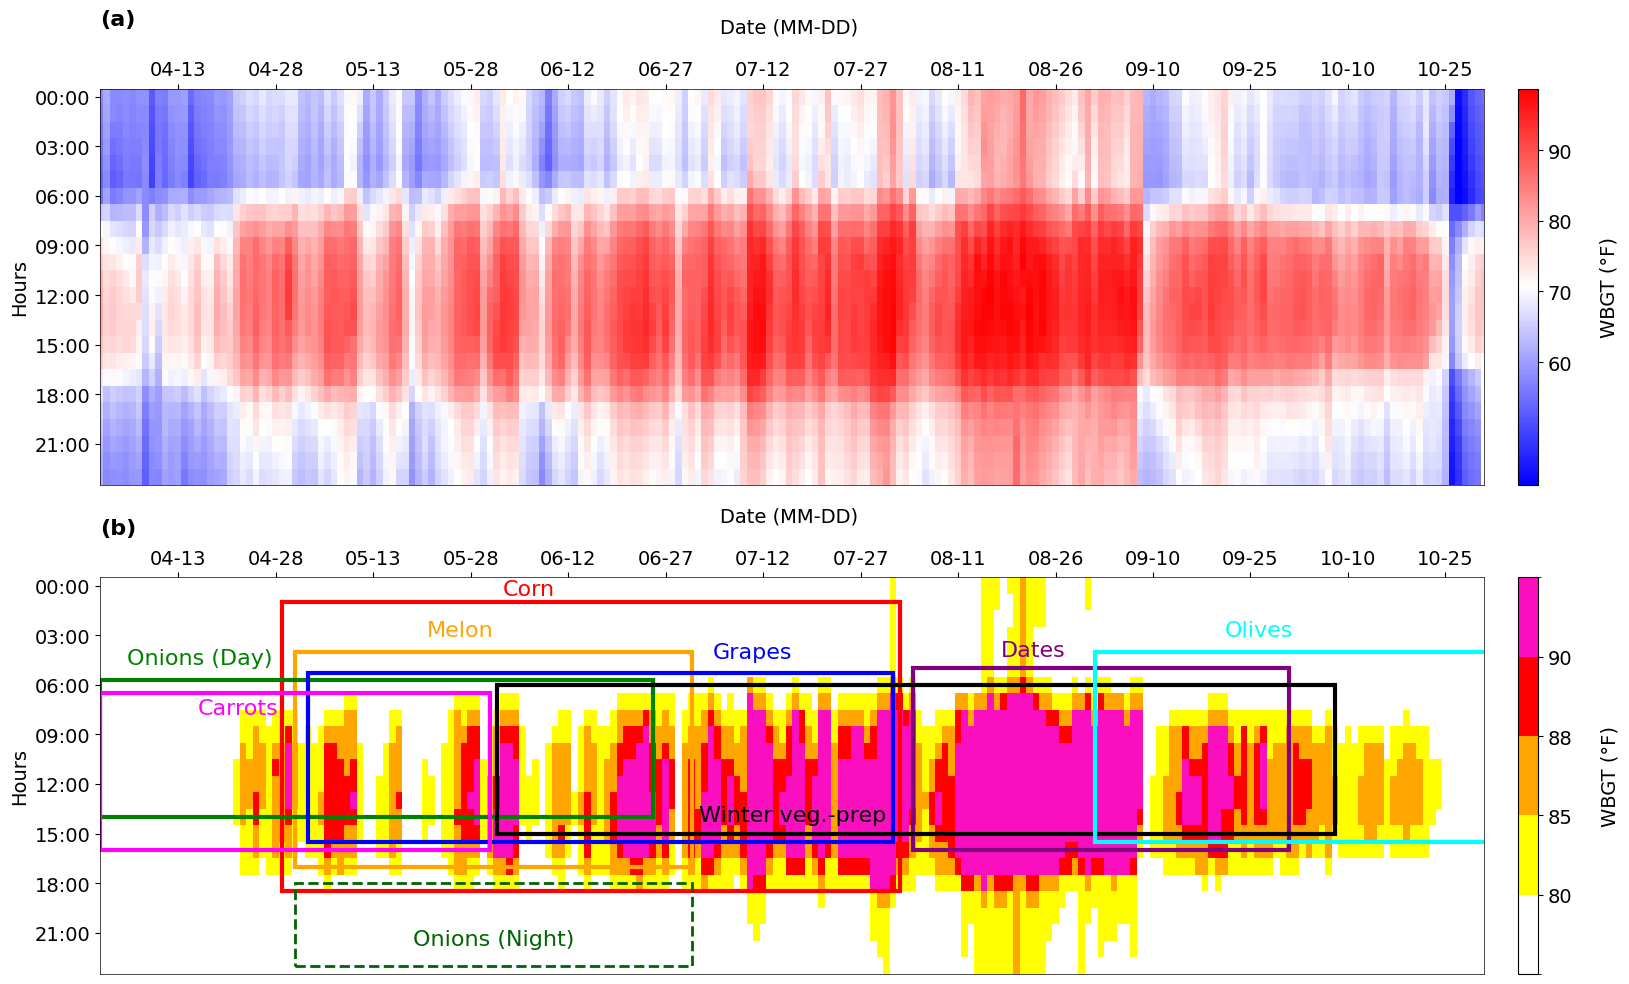

In [ ]:
# Plot the Hour-month plot of WBGT and its color coded representation overlain by crop harvest/land preparation windows

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as patches
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

# Dummy placeholder for WBGT data (shape [24, 214])
# Replace this with your actual data
# wbgt_f_iv_diurnal_mean = ...

# Time setup
start_date = np.datetime64('2020-04-01')
end_date = np.datetime64('2020-10-31')
dates = np.arange(start_date, end_date + np.timedelta64(1, 'D'), np.timedelta64(1, 'D'))

x = mdates.date2num(dates)  # Convert dates to numeric
y = -np.arange(24)  # Inverted so 0 at top

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(18, 10))

# --- Plot 1: Heatmap with default colormap ---
c = ax1.pcolormesh(x, y, wbgt_f_iv_diurnal_mean, cmap="bwr", shading="auto")
cbar = plt.colorbar(c, ax=ax1, ticks=[60, 70, 80, 90], pad=0.02)
cbar.set_label("WBGT (°F)", labelpad=20)
cbar.ax.set_yticklabels(["60", "70", "80", "90"])

ax1.text(0, 1.15, '(a)', transform=ax1.transAxes,
         fontsize=16, fontweight='bold', va='bottom', ha='left')
ax1.set_xlabel("Date (MM-DD) \n")
ax1.xaxis.set_label_position('top')
ax1.xaxis.tick_top()
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=15))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax1.tick_params(axis='x', labelsize=14)
ax1.set_xlim(pd.to_datetime('2020-04-01'), pd.to_datetime('2020-10-31'))

ax1.set_ylabel("Hours")
y_ticks = -np.arange(0, 24, 3)
y_labels = np.arange(0, 24, 3)
ax1.set_yticks(y_ticks)
ax1.set_yticklabels([f"{h:02d}:00" for h in y_labels])

# --- Plot 2: Heatmap with custom color scale ---
bounds = [0, 80, 85, 88, 90, 1150]
colors = [[1, 1, 1], [1, 1, 0], [1, 0.647, 0], [1, 0, 0], [0.98, 0.0586, 0.75]]
cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(bounds, cmap.N)

c = ax2.pcolormesh(x, y, wbgt_f_iv_diurnal_mean, cmap=cmap, norm=norm, shading="auto")
cbar = plt.colorbar(c, ax=ax2, ticks=[80, 85, 88, 90], pad=0.02)
cbar.set_label("WBGT (°F)", labelpad=20)
cbar.ax.set_yticklabels(["80", "85", "88", "90"])

ax2.text(0, 1.1, '(b)', transform=ax2.transAxes,
         fontsize=16, fontweight='bold', va='bottom', ha='left')
ax2.set_xlabel("Date (MM-DD) \n")
ax2.xaxis.set_label_position('top')
ax2.xaxis.tick_top()
ax2.xaxis.set_major_locator(mdates.DayLocator(interval=15))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax2.tick_params(axis='x', labelsize=14)
ax2.set_xlim(pd.to_datetime('2020-04-01'), pd.to_datetime('2020-10-31'))

ax2.set_ylabel("Hours")
ax2.set_yticks(y_ticks)
ax2.set_yticklabels([f"{h:02d}:00" for h in y_labels])

# --- Define crop windows ---
crop_windows_clean = {
    'Corn': ((1, 18.5), (28, 123)),
    'Melon': ((4, 17), (30, 91)),
    'Onions (Day)': ((5.7, 14), (0, 85)),
    'Grapes': ((5.3, 15.5), (32, 122)),
    'Dates': ((5, 16), (125, 183)),
    'Winter veg.-prep': ((6, 15), (61, 190)),
    'Olives': ((4, 15.5), (153, 214)),
    'Carrots': ((6.5, 16), (0, 60)),
}
onion_hour_ranges = [(18, 23)]
onion_month_range = (30, 91)

rect_colors = ['red', 'orange', 'green', 'blue', 'purple', 'black', 'cyan', 'magenta']

def index_to_date(idx):
    return mdates.date2num(start_date + np.timedelta64(idx, 'D'))

# --- Draw rectangles and label above the top edge ---
for i, (crop, ((h_start, h_end), (m_start, m_end))) in enumerate(crop_windows_clean.items()):
    color = rect_colors[i % len(rect_colors)]
    x_start = index_to_date(m_start)
    x_end = index_to_date(m_end)
    y_start = -h_end
    y_end = -h_start

    rect = patches.Rectangle(
        (x_start, y_start),
        x_end - x_start,
        h_end - h_start,
        linewidth=3,
        edgecolor=color,
        facecolor='none'
    )
    ax2.add_patch(rect)

    # Adjust label position for specific crops
    if crop == 'Onions (Day)':
        label_x = (x_start + x_end) / 2 - 16
        label_y = y_end + 0.7
    elif crop == 'Carrots':
        label_x = (x_start + x_end) / 2 - 2.5
        label_y = y_end - 1.5
    elif crop == 'Winter veg.-prep':
        label_x = (x_start + x_end) / 2 - 4.5
        label_y = y_end - 8.5
    elif crop == 'Dates':
        label_x = (x_start + x_end) / 2 - 5.5
        label_y = y_end + 0.5
    elif crop == 'Grapes':
        label_x = (x_start + x_end) / 2 + 29.5
        label_y = y_end + 0.7
    elif crop == 'Corn':
        label_x = (x_start + x_end) / 2 - 5.5
        label_y = y_end + 0.2
    else:
        label_x = (x_start + x_end) / 2
        label_y = y_end + 0.7

    ax2.text(label_x, label_y, crop,
             fontsize=16, color=color, ha='right', va='bottom')

# --- Onions (Night) special case ---
onion_color = 'darkgreen'
for h_start, h_end in onion_hour_ranges:
    x_start = index_to_date(onion_month_range[0])
    x_end = index_to_date(onion_month_range[1])
    y_start = -h_end
    y_end = -h_start

    rect = patches.Rectangle(
        (x_start, y_start),
        x_end - x_start,
        h_end - h_start,
        linewidth=2,
        edgecolor=onion_color,
        facecolor='none',
        linestyle='--'
    )
    ax2.add_patch(rect)

# Label above the top edge of the highest night rectangle
ax2.text((x_start + x_end) / 2, -h_start - 4, "Onions (Night)",
         fontsize=16, color=onion_color, ha='center', va='bottom')

# Make the border (spines) thicker for both subplots
for ax in [ax1, ax2]:
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

plt.tight_layout()
plt.show()
